# 00 — EDA: datos y features causales

Primer eslabón del banco de pruebas de detección de **regímenes de mercado** (Capa 1 del TFM). Un *régimen* es un periodo en el que el comportamiento estadístico del mercado —volatilidad, correlaciones, signo de los retornos— es relativamente homogéneo, típicamente alternando fases de **calma** y de **crisis**. Detectarlo a tiempo y **sin mirar al futuro** es el problema que los 12 detectores del banco abordan bajo un marco común; la tesis no es "cuál es el mejor detector", sino "cuál es el mejor para qué".

Antes de comparar nada hay que fijar el terreno: de dónde salen los datos, qué ventana temporal es común a todas las series, qué forma tienen las distribuciones (las *colas gordas* que romperán el supuesto gaussiano de algunos modelos) y, sobre todo, construir features **causales** —que en cada fecha *t* solo usan información disponible hasta *t*, sin *look-ahead*—. Ese es el objetivo de esta **FASE 1**:

- Cobertura y fechas de inicio por serie (set ampliado, **sin imputar**).
- Ventana común resultante y periodos faltantes.
- Estadísticos, **fat tails** (kurtosis), correlaciones.
- Suelos de drawdown del S&P 500 (que alimentan `DRAWDOWN_TROUGHS`).
- Construcción de **features causales** + test de no look-ahead.

Resumen en `docs/memory/01_data_and_eda.md`.

## Índice

La FASE 1 recorre tres bloques: primero **de dónde salen los datos** y por qué la ventana común empieza donde empieza; después **cómo se comportan** estadísticamente (las colas gordas que condicionan el diseño de detectores); y por último el **núcleo metodológico**, las 15 features causales y su verificación de no look-ahead. Cada enlace salta a su sección.

**A · Inventario y procedencia de los datos**
1. [Cobertura y fechas de inicio por serie (sin imputar)](#sec-1)
2. [Timeline de disponibilidad — ¿por qué la ventana arranca en 2007-04?](#sec-2)  · *fig. `eda_coverage_timeline.png`*
3. [Procedencia de los datos (yfinance + fallbacks documentados)](#sec-3)
4. [Periodos faltantes dentro del rango de cada serie](#sec-4)

**B · Comportamiento estadístico de los retornos**
5. [Estadísticos descriptivos de los retornos diarios](#sec-5)
6. [Fat tails: skew y kurtosis de exceso](#sec-6)  · *fig. `eda_fat_tails.png`*
7. [Retornos del S&P 500: crisis vs calma](#sec-7)  · *fig. `eda_returns_crisis_vs_calm.png`*
8. [Correlaciones incondicionales entre retornos](#sec-8)  · *fig. `eda_corr.png`*

**C · Patrón oro y dinámica de régimen**
9. [S&P 500, drawdown y ventanas de crisis / falsos positivos](#sec-9)  · *fig. `eda_sp500_drawdown.png`*
10. [Suelos de drawdown calculados (`DRAWDOWN_TROUGHS`)](#sec-10)
11. [Correlación rolling S&P 500 / Treasuries (Gulko 2002)](#sec-11)  · *fig. `eda_rolling_corr.png`*

**D · Features causales (núcleo metodológico)**
12. [Construcción de 15 features + test de no look-ahead](#sec-12)  · *artefacto `features.parquet`*
13. [Panel-resumen del feature space (15 small multiples)](#sec-13)  · *fig. `eda_features_overview.png`*
14. [Tabla de estadísticos por feature](#sec-14)  · *fig. `eda_features_stats.png`*

[· Conclusión FASE 1 ·](#sec-fin)

> **Productos del notebook.** Siete figuras en `results/` (`eda_coverage_timeline`, `eda_fat_tails`, `eda_returns_crisis_vs_calm`, `eda_corr`, `eda_sp500_drawdown`, `eda_rolling_corr`, `eda_features_overview`, más la tabla `eda_features_stats`) y un único artefacto de datos: `data/processed/features.parquet`, con las **15 features causales** sobre las que trabajarán los 12 detectores. Este notebook **no** escribe métricas de detector (`metrics_master.csv`); su trabajo es fijar el terreno común.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Localizar raíz del repo (contiene src/)
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
from src import data_loader as dl, features as ft, evaluation as ev, viz
viz.use_house_style()   # paleta y estilo homogéneos con el resto del banco (colores de régimen consistentes)

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
print('Panel crudo:', raw.shape, '| union de fechas', raw.index.min().date(), '->', raw.index.max().date())
raw.tail(3)

Panel crudo: (10591, 9) | union de fechas 1985-01-02 -> 2026-06-16


,SP500,VIX,MOVE,TLT,IEF,HYG,GOLD,DXY,YIELD_10Y_3M
date,,,,,,,,,
2026-06-12,7431.459961,17.68,69.360001,85.769997,94.180000,79.940002,386.540009,99.750000,0.869
2026-06-15,NaN,NaN,NaN,85.720001,94.279999,NaN,NaN,NaN,NaN
2026-06-16,7543.810059,15.98,NaN,86.050003,94.425003,80.025002,396.859985,99.595001,0.816


<a id="sec-1"></a>
## 1. Cobertura y fechas de inicio por serie (sin imputar)

Empezamos por el inventario de materia prima. Cada serie arranca en su fecha real y **no se imputa** ningún hueco: preferimos una ventana más corta pero honesta a rellenar datos que nunca existieron. La última fila (`VENTANA_COMUN`) es la **intersección** de todas las series sin NaN —el rango sobre el que podrán trabajar los detectores multivariantes—; como se verá, la gobierna la serie que arranca más tarde (HYG, 2007).

In [2]:
cov = dl.coverage_report(raw, save=False)
cov

,serie,inicio,fin,n_obs,pct_nan_en_rango
0,SP500,1985-01-02,2026-06-16,10443,1.397
1,DXY,1985-01-02,2026-06-16,10584,0.066
2,YIELD_10Y_3M,1985-01-02,2026-06-16,10397,1.832
3,VIX,1990-01-02,2026-06-16,9181,1.195
4,TLT,2002-07-30,2026-06-16,6009,0.315
5,IEF,2002-07-30,2026-06-16,6009,0.315
6,MOVE,2002-11-12,2026-06-12,5831,2.033
7,GOLD,2004-11-18,2026-06-16,5426,0.221
8,HYG,2007-04-11,2026-06-16,4826,0.103
9,VENTANA_COMUN,2007-04-11,2026-06-12,4737,0.000


<a id="sec-2"></a>
## 2. Timeline de disponibilidad de las series

La tabla anterior tiene una lectura visual mucho más elocuente: un **diagrama de rangos** (tipo Gantt) que dibuja, para cada serie, su tramo realmente disponible —de su primer dato no-NaN a su último—. La utilidad es inmediata: la ventana común no la fija un criterio arbitrario, sino la **serie que arranca más tarde**. En este set ampliado esa serie es **HYG** (ETF de crédito *high yield*, cotiza desde 2007), que empuja el comienzo de toda la evaluación multivariante a **2007-04-11**.

Es una restricción dura y deliberada: en lugar de imputar HYG hacia atrás para ganar la crisis DotCom (2000-2002), aceptamos perder ese episodio en el set completo y lo dejamos como referencia evaluable solo por detectores de features con histórico largo (S&P 500 + VIX, desde 1990). La franja roja marca la ventana común; la barra resaltada, la serie que la gobierna.

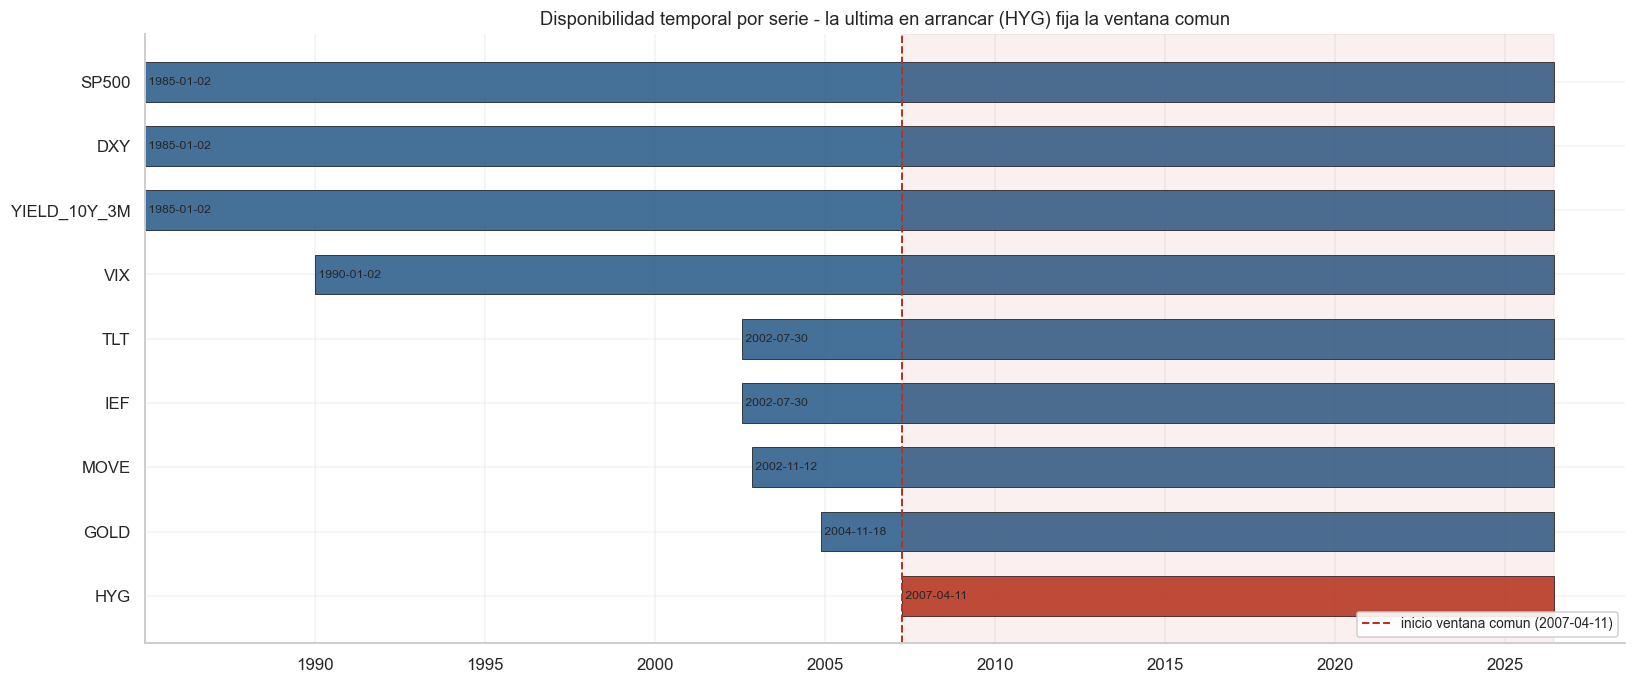

In [3]:
# Rango temporal real (primer y ultimo dato no-NaN) de cada serie, ordenado por
# fecha de inicio. La serie que arranca MAS TARDE fija el comienzo de la ventana
# comun; la que termina ANTES, el final.
spans = []
for c in raw.columns:
    s = raw[c].dropna()
    if not s.empty:
        spans.append((c, s.index.min(), s.index.max()))
spans.sort(key=lambda r: r[1])  # por fecha de inicio
common_start = max(t0 for _, t0, _ in spans)
common_end = min(t1 for _, _, t1 in spans)

fig, ax = plt.subplots(figsize=(15, 0.55 * len(spans) + 1.4))
for i, (name, t0, t1) in enumerate(spans):
    binding = (t0 == common_start)  # la serie que gobierna la ventana comun (HYG)
    ax.barh(i, (t1 - t0).days, left=t0, height=0.62,
            color=viz.C_CRISIS if binding else viz.C_LONG, alpha=0.88,
            edgecolor='black', linewidth=0.5)
    ax.text(t0, i, ' ' + t0.date().isoformat(), va='center', ha='left', fontsize=8)
ax.axvspan(common_start, common_end, color=viz.C_CRISIS, alpha=0.07)
ax.axvline(common_start, color=viz.C_CRISIS, ls='--', lw=1.3,
           label=f'inicio ventana comun ({common_start.date()})')
ax.set_yticks(range(len(spans))); ax.set_yticklabels([s[0] for s in spans])
ax.invert_yaxis()
ax.set_title('Disponibilidad temporal por serie - la ultima en arrancar (HYG) fija la ventana comun')
ax.legend(loc='lower right', framealpha=0.9)
fig.tight_layout(); fig.savefig(RESULTS / 'eda_coverage_timeline.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="sec-3"></a>
## 3. Procedencia de los datos (yfinance + fallbacks documentados)

La trazabilidad de las fuentes es parte del estándar de honestidad del trabajo: donde una fuente falló, se dice y se documenta el sustituto, en vez de rellenar en silencio.

FRED (`fredgraph.csv`) resultó **inaccesible** en este entorno (timeouts). Sustituciones documentadas, sin inventar ni omitir:
- **DXY** → yfinance `DX-Y.NYB` (índice dólar ICE clásico).
- **Curva 10Y-3M** → proxy real `^TNX − ^IRX` (FRED `T10Y3M` no respondió).
- **HY OAS** → omitido (respuesta FRED truncada); crédito cubierto por HYG y spread HYG−IEF.

In [4]:
import json
prov = json.loads((ROOT / 'data' / 'raw' / 'provenance.json').read_text(encoding='utf-8'))
pd.Series(prov, name='fuente').to_frame()

,fuente
SP500,yfinance:^GSPC
VIX,yfinance:^VIX
MOVE,yfinance:^MOVE
TLT,yfinance:TLT
IEF,yfinance:IEF
HYG,yfinance:HYG
GOLD,yfinance:GLD
DXY,yfinance:DX-Y.NYB
TNX,yfinance:^TNX
IRX,yfinance:^IRX


<a id="sec-4"></a>
## 4. Periodos faltantes dentro del rango de cada serie

Fijada la ventana común, conviene cuantificar los huecos internos: NaN dentro del propio rango de cada serie (festivos desalineados entre fuentes, cierres). No se imputan; los detectores trabajan sobre la ventana común con `dropna`, de modo que estos huecos no introducen valores inventados en la evaluación.

In [5]:
rng = pd.date_range(raw.index.min(), raw.index.max(), freq='B')
miss = {}
for c in raw.columns:
    s = raw[c]
    first = s.first_valid_index()
    within = s.loc[first:]
    miss[c] = int(within.isna().sum())
pd.Series(miss, name='NaN_dentro_de_rango').sort_values(ascending=False).to_frame()

,NaN_dentro_de_rango
YIELD_10Y_3M,194
SP500,148
MOVE,123
VIX,111
TLT,19
IEF,19
GOLD,12
DXY,7
HYG,5


<a id="sec-5"></a>
## 5. Estadísticos descriptivos de los retornos diarios

Con los datos ya saneados, pasamos a caracterizar su comportamiento. Trabajamos con retornos log de precios (aditivos en el tiempo y mejor comportados para modelar); los niveles (VIX, MOVE, pendiente de la curva) se describen aparte porque no son retornos sino estados.

In [6]:
px_cols = ['SP500','TLT','IEF','HYG','GOLD','DXY']
rets = np.log(raw[px_cols] / raw[px_cols].shift(1)).dropna(how='all')
desc = rets.describe().T[['mean','std','min','max']]
desc['ann_vol'] = rets.std() * np.sqrt(252)
desc.round(5)

,mean,std,min,max,ann_vol
SP500,0.00036,0.01147,-0.22900,0.10957,0.18212
TLT,0.00015,0.00901,-0.06901,0.07250,0.14309
IEF,0.00015,0.00429,-0.02539,0.03369,0.06808
HYG,0.00019,0.00686,-0.08444,0.11573,0.10883
GOLD,0.00040,0.01147,-0.10841,0.10697,0.18200
DXY,-0.00004,0.00513,-0.03546,0.02861,0.08143


<a id="sec-6"></a>
## 6. Fat tails: skew y kurtosis (exceso)

Aquí aparece el primer hallazgo con consecuencias para el diseño de detectores. Los retornos son **leptocúrticos** (*colas gordas*: los eventos extremos son mucho más frecuentes de lo que predeciría una normal), un hecho que el supuesto gaussiano de modelos como el HMM **subestima** por construcción. La kurtosis de exceso ≫ 0 y el test de normalidad Jarque-Bera lo hacen explícito. No es un detalle estético: anticipa por qué un detector gaussiano puede infra-reaccionar justo en los días de cola que definen una crisis.

In [7]:
tail = pd.DataFrame({
    'skew': rets.skew(),
    'excess_kurtosis': rets.kurtosis(),  # Fisher: 0 = normal
})
jb = {c: stats.jarque_bera(rets[c].dropna()) for c in rets.columns}
tail['jarque_bera_stat'] = {c: jb[c][0] for c in rets.columns}
tail['jb_p_value'] = {c: jb[c][1] for c in rets.columns}
tail.round(3)

,skew,excess_kurtosis,jarque_bera_stat,jb_p_value
SP500,-1.160,25.583,282739.752,0.0
TLT,-0.021,3.429,2927.213,0.0
IEF,0.051,2.497,1554.289,0.0
HYG,0.314,39.590,314179.664,0.0
GOLD,-0.460,6.806,10614.741,0.0
DXY,-0.099,2.247,2238.444,0.0


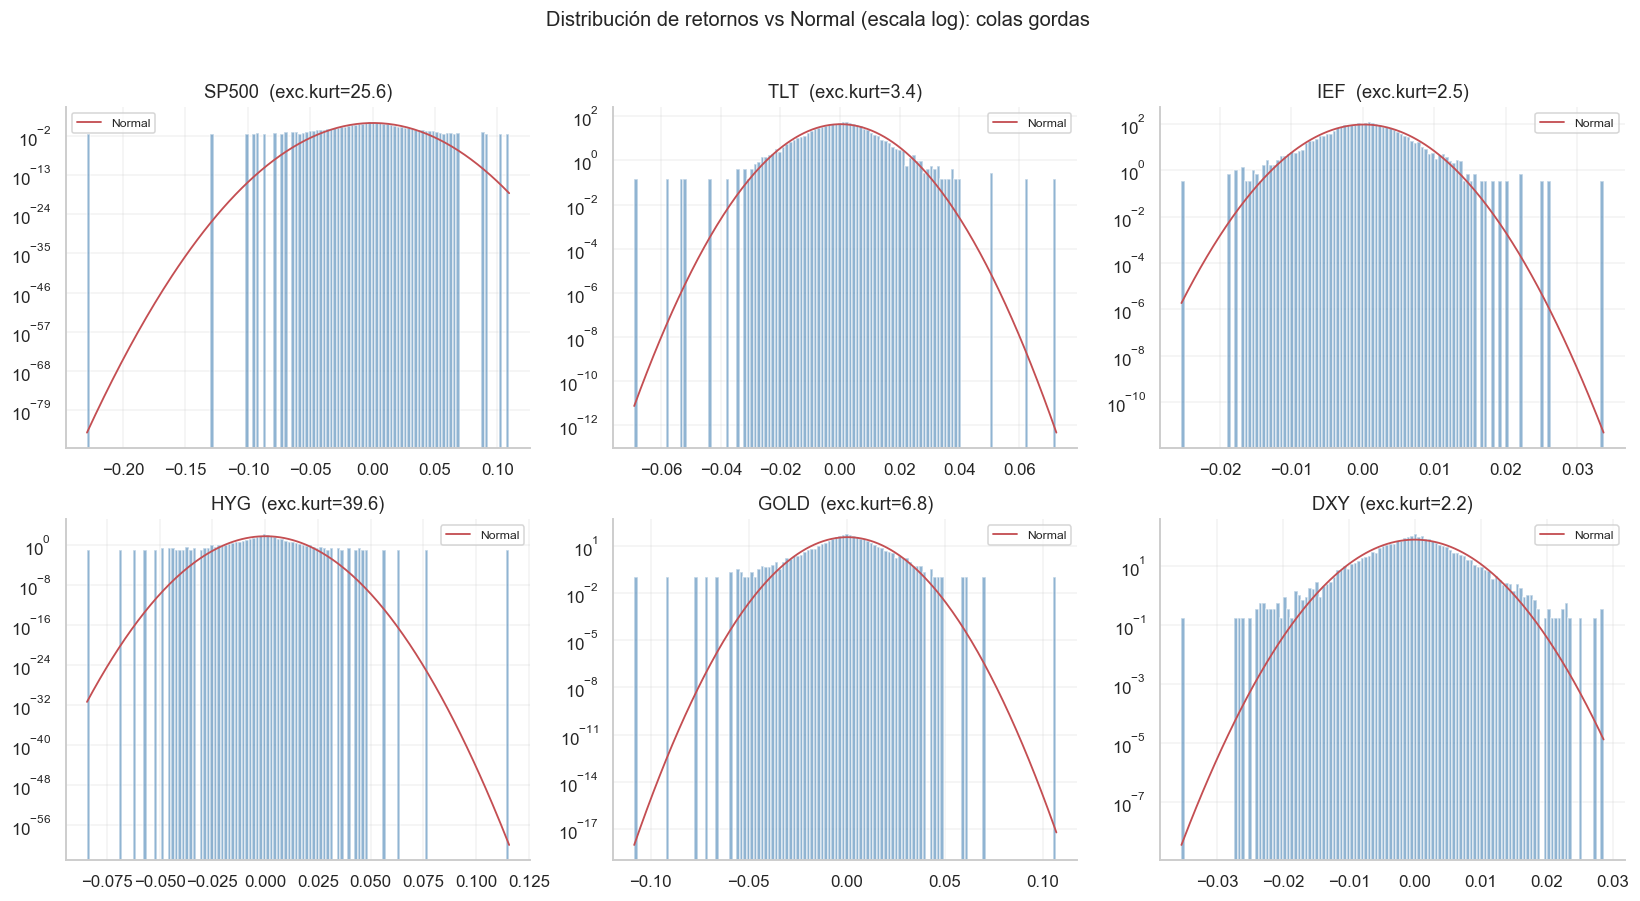

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), px_cols):
    r = rets[c].dropna()
    ax.hist(r, bins=120, density=True, alpha=0.6, color='steelblue')
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', lw=1.2, label='Normal')
    ax.set_title(f'{c}  (exc.kurt={r.kurtosis():.1f})')
    ax.set_yscale('log'); ax.legend(fontsize=8)
fig.suptitle('Distribución de retornos vs Normal (escala log): colas gordas', y=1.02)
fig.tight_layout(); fig.savefig(RESULTS / 'eda_fat_tails.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="sec-7"></a>
## 7. Retornos del S&P 500: crisis vs calma

La kurtosis de la sección anterior es un número agregado sobre **toda** la muestra; conviene ver de dónde viene. Si partimos los retornos del S&P 500 en dos poblaciones —los días que caen dentro de las **ventanas de crisis** sistémicas cableadas en `evaluation.CRISIS_WINDOWS` (2008, 2011, 2020, 2022) frente al resto, la **calma**— la diferencia es estructural, no de matiz:

- En **calma**, la distribución es estrecha y casi simétrica: el día típico apenas se mueve.
- En **crisis**, se ensancha drásticamente (mayor desviación) y se vuelve marcadamente asimétrica hacia pérdidas, con las colas que en agregado vimos como leptocurtosis.

Esta partición binaria **no es un detector** —usa fechas conocidas a posteriori— sino la *partición de referencia* del *event study*: ilustra por qué un régimen es algo más que "vol alta" y por qué un modelo gaussiano de un solo estado, al promediar ambas poblaciones, **subestima** justo los días que definen una crisis. El histograma se dibuja en escala log en el eje vertical para que las colas, raras por definición, sean visibles. Reutilizamos el helper de casa `viz.plot_distribution_by_regime` (misma paleta de régimen que el resto del banco).

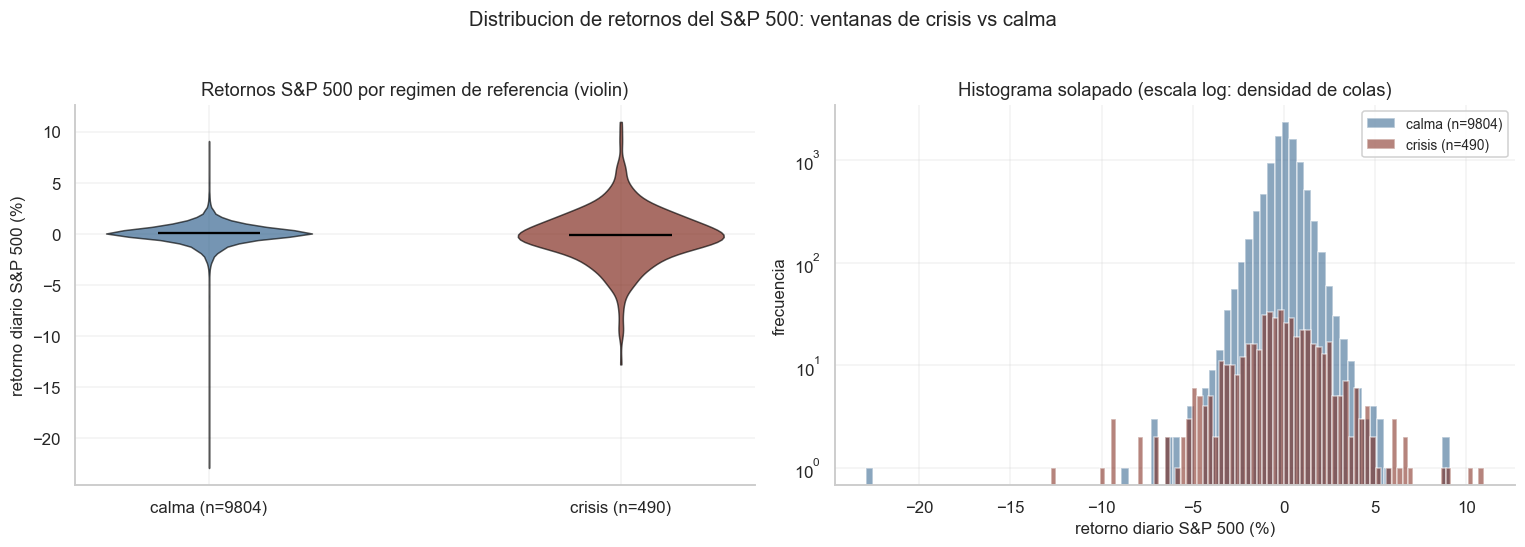

Retorno diario del S&P 500 por regimen de referencia:
   calma: n= 9804  vol_diaria= 1.01%  min=-22.90%  exc.kurt= 32.2
  crisis: n=  490  vol_diaria= 2.70%  min=-12.77%  exc.kurt=  2.9


In [9]:
# Etiqueta binaria CALMA(0) / CRISIS(1) por dia, derivada SOLO de las ventanas de
# crisis sistemica de evaluation.py. NO es un detector (usa fechas conocidas a
# posteriori): es la particion de referencia para contrastar la forma de las colas.
sp_ret = rets['SP500'].dropna()
crisis_mask = pd.Series(0, index=sp_ret.index, name='regimen_ref')
for a, b in ev.CRISIS_WINDOWS.values():
    crisis_mask.loc[(sp_ret.index >= pd.Timestamp(a)) & (sp_ret.index <= pd.Timestamp(b))] = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
viz.plot_distribution_by_regime(
    sp_ret * 100, crisis_mask, labels={0: 'calma', 1: 'crisis'}, kind='violin',
    ax=axes[0], xlabel='retorno diario S&P 500 (%)',
    title='Retornos S&P 500 por regimen de referencia (violin)')
viz.plot_distribution_by_regime(
    sp_ret * 100, crisis_mask, labels={0: 'calma', 1: 'crisis'}, kind='hist', bins=80,
    ax=axes[1], xlabel='retorno diario S&P 500 (%)',
    title='Histograma solapado (escala log: densidad de colas)')
axes[1].set_yscale('log')
fig.suptitle('Distribucion de retornos del S&P 500: ventanas de crisis vs calma', y=1.03)
fig.tight_layout(); fig.savefig(RESULTS / 'eda_returns_crisis_vs_calm.png', dpi=110, bbox_inches='tight')
plt.show()

# Resumen numerico: la crisis multiplica la volatilidad y engorda las colas.
print('Retorno diario del S&P 500 por regimen de referencia:')
for lab, g in [('calma', sp_ret[crisis_mask == 0]), ('crisis', sp_ret[crisis_mask == 1])]:
    print(f'  {lab:>6}: n={len(g):5d}  vol_diaria={g.std()*100:5.2f}%  '
          f'min={g.min()*100:6.2f}%  exc.kurt={g.kurtosis():5.1f}')

<a id="sec-8"></a>
## 8. Correlaciones entre retornos

La correlación **incondicional** (sobre toda la muestra) resume la estructura de dependencia media entre activos. Pero el objeto del proyecto es la dependencia **condicional al régimen** —la que cambia entre calma y crisis—: justo lo que esta foto promedio esconde y lo que los detectores deben capturar. La sección 11 muestra esa parte dinámica.

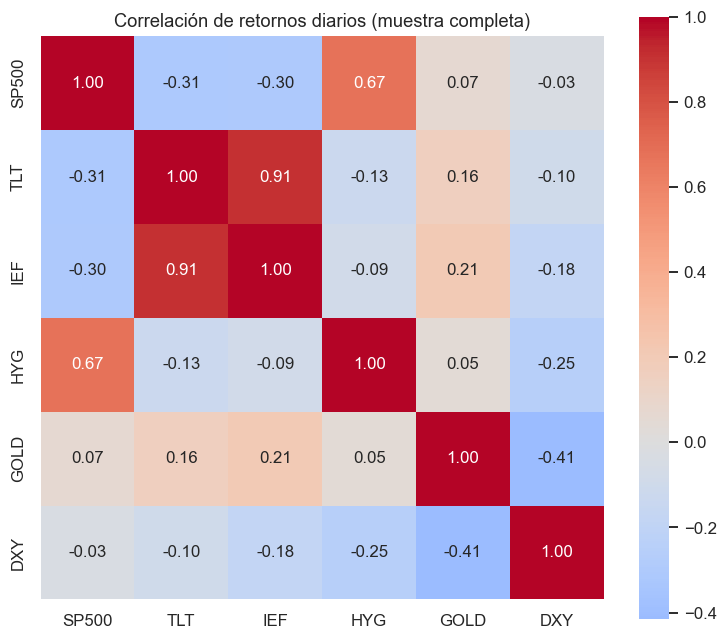

In [10]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlación de retornos diarios (muestra completa)')
fig.tight_layout(); fig.savefig(RESULTS / 'eda_corr.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="sec-9"></a>
## 9. S&P 500, drawdown y ventanas de crisis / falsos positivos

Definimos ahora el *patrón oro* contra el que se medirá cada detector. El **drawdown** es la caída acumulada desde el último máximo (∈[−1,0]); sobre él marcamos dos tipos de ventana ya cableadas en `evaluation.py`:
- **crisis** sistémicas (2008, 2011, 2020, 2022): periodos donde un buen detector debe encenderse —alta **cobertura**, es decir, alto % de días de la ventana marcados como crisis—.
- **trampas** o falsos positivos (taper tantrum 2013, sell-off Q4 2018): correcciones rápidas que NO son crisis sistémicas y donde encenderse penaliza la especificidad.

Todas caen dentro de la ventana común de datos (≥ 2007-04-11), de modo que son evaluables. Conviene recordar que son solo **n≈4 crisis**: suficiente para describir comportamiento, no para tests de significancia.

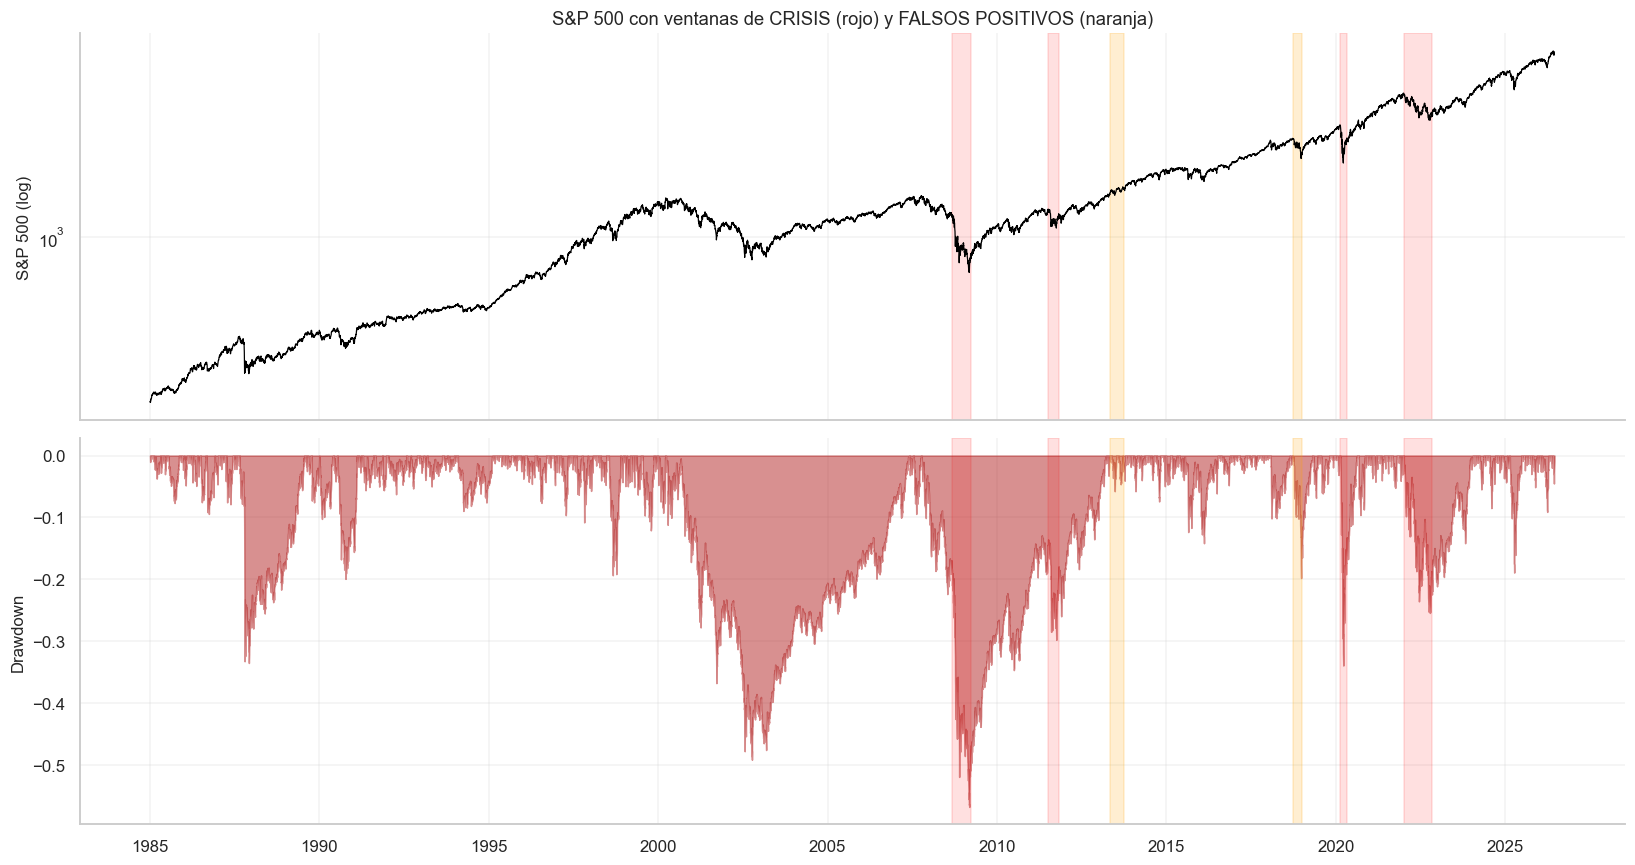

In [11]:
spx = raw['SP500'].dropna()
dd = spx / spx.expanding().max() - 1.0
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ax1.plot(spx.index, spx, color='black', lw=0.8); ax1.set_yscale('log'); ax1.set_ylabel('S&P 500 (log)')
ax2.fill_between(dd.index, dd, 0, color='firebrick', alpha=0.5); ax2.set_ylabel('Drawdown')
for name, (a, b) in ev.CRISIS_WINDOWS.items():
    for ax in (ax1, ax2): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
    for ax in (ax1, ax2): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax1.set_title('S&P 500 con ventanas de CRISIS (rojo) y FALSOS POSITIVOS (naranja)')
fig.tight_layout(); fig.savefig(RESULTS / 'eda_sp500_drawdown.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="sec-10"></a>
## 10. Suelos de drawdown CALCULADOS (alimentan `DRAWDOWN_TROUGHS`)

El **suelo** (*trough*) de cada episodio —la fecha de drawdown mínimo— es el ancla temporal para medir el *lead/lag* de un detector: cuántos días se adelanta (señal antes del fondo) o se retrasa su aviso de crisis. Se calculan desde la serie real del S&P 500, no a mano, para que la referencia sea reproducible. Estos valores están cableados en `evaluation.DRAWDOWN_TROUGHS`.

In [12]:
episodes = {
    'DotCom_2002':   ('2000-01-01','2003-06-30'),
    'GFC_2008':      ('2007-10-01','2009-12-31'),
    'EuroDebt_2011': ('2011-04-01','2012-06-30'),
    'COVID_2020':    ('2020-01-01','2020-06-30'),
    'Inflation_2022':('2022-01-01','2023-06-30'),
}
rows = []
for name, (a, b) in episodes.items():
    seg = dd.loc[a:b]
    rows.append({'episodio': name, 'trough': seg.idxmin().date().isoformat(),
                 'max_drawdown': round(float(seg.min()), 3),
                 'en_ventana_comun': seg.idxmin() >= pd.Timestamp('2007-04-11')})
troughs_df = pd.DataFrame(rows)
print('DRAWDOWN_TROUGHS en evaluation.py:', ev.DRAWDOWN_TROUGHS)
troughs_df

DRAWDOWN_TROUGHS en evaluation.py: {'GFC_2008': '2009-03-09', 'EuroDebt_2011': '2011-10-03', 'COVID_2020': '2020-03-23', 'Inflation_2022': '2022-10-12'}


,episodio,trough,max_drawdown,en_ventana_comun
0,DotCom_2002,2002-10-09,-0.491,False
1,GFC_2008,2009-03-09,-0.568,True
2,EuroDebt_2011,2011-10-03,-0.298,True
3,COVID_2020,2020-03-23,-0.339,True
4,Inflation_2022,2022-10-12,-0.254,True


<a id="sec-11"></a>
## 11. Correlación rolling S&P 500 / Treasuries (Gulko 2002)

Esta es la cara **dinámica** de la sección 6. La correlación equity/bonos **cambia de signo entre regímenes**: suele ser negativa en calma (los bonos diversifican el equity) y puede romperse o invertirse en crisis (cuando "todo cae a la vez"). Esa inestabilidad es informativa por sí misma, y por eso se incorpora como feature del detector (`corr_spx_bond`).

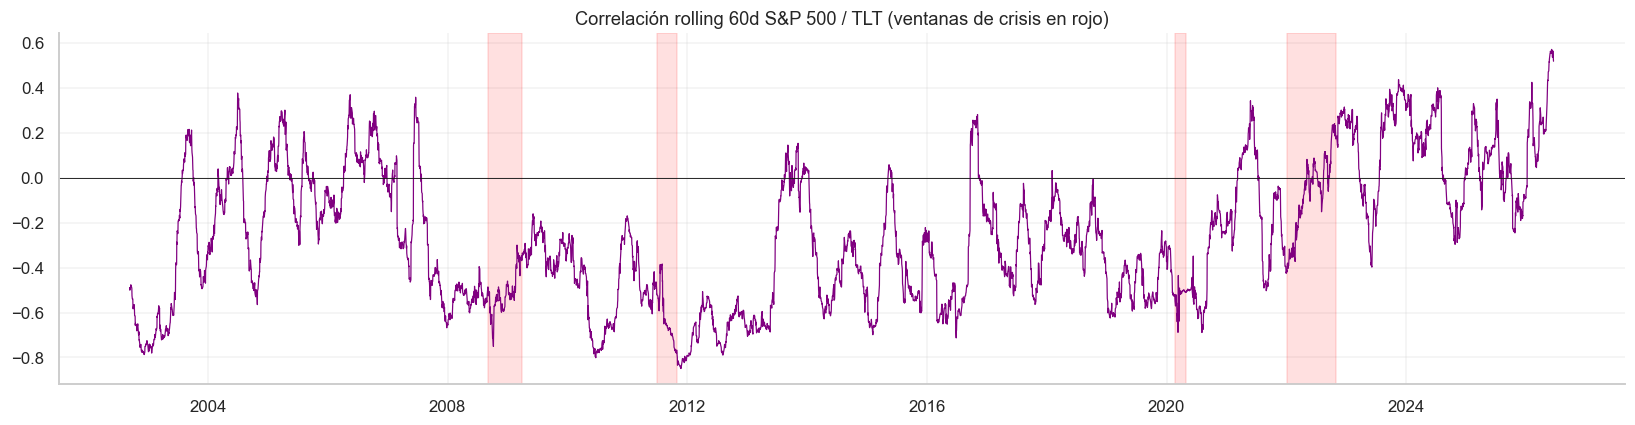

In [13]:
spx_ret = np.log(raw['SP500']/raw['SP500'].shift(1))
tlt_ret = np.log(raw['TLT']/raw['TLT'].shift(1))
rcorr = spx_ret.rolling(60, min_periods=30).corr(tlt_ret).dropna()
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(rcorr.index, rcorr, color='purple', lw=0.8); ax.axhline(0, color='k', lw=0.6)
for name, (a, b) in ev.CRISIS_WINDOWS.items():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
ax.set_title('Correlación rolling 60d S&P 500 / TLT (ventanas de crisis en rojo)')
fig.tight_layout(); fig.savefig(RESULTS / 'eda_rolling_corr.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="sec-12"></a>
## 12. Features causales + verificación de no look-ahead

El núcleo metodológico del banco: ninguna feature puede usar información del futuro. `features.build_features` produce **15 features causales** —por ejemplo, *z-scores expanding*, que estandarizan cada serie usando solo la media y la desviación acumuladas hasta *t*, nunca las de la muestra completa—. `assert_causal` lo verifica de forma operativa: trunca la entrada en una fecha y comprueba que el pasado no cambia al añadir futuro (`max_abs_diff` debe ser exactamente 0 para las 15). Es la garantía de que las evaluaciones posteriores no están contaminadas por *look-ahead*.

In [14]:
feats = ft.build_features(raw, save=True)
print('Features:', feats.shape, '| ventana efectiva:', feats.index.min().date(), '->', feats.index.max().date())
feats.describe().T[['mean','std','min','max']].round(3)

Features: (4665, 15) | ventana efectiva: 2007-07-06 -> 2026-06-12


,mean,std,min,max
SP500_ret_z,-0.005,1.097,-11.191,9.142
SP500_vol_z,0.126,1.207,-1.219,8.265
VIX_level_z,0.048,1.149,-1.306,8.769
VIX_change_z,0.012,1.321,-13.031,15.410
MOVE_level_z,-0.137,1.048,-1.548,5.814
TLT_ret_z,-0.014,1.145,-8.042,8.264
IEF_ret_z,-0.018,1.024,-6.131,7.441
HYG_ret_z,-0.002,0.774,-9.366,9.852
credit_spread_z,0.007,0.773,-8.788,8.755
yield_slope_z,-0.416,1.047,-3.078,1.773


In [15]:
causal = ft.assert_causal(raw, cut='2015-01-01')
assert causal['causal_ok'].all(), 'HAY FEATURES NO CAUSALES'
print('TODAS las features son causales (max_abs_diff == 0):')
causal

TODAS las features son causales (max_abs_diff == 0):


,feature,max_abs_diff,causal_ok
0,SP500_ret_z,0.0,True
1,SP500_vol_z,0.0,True
2,VIX_level_z,0.0,True
3,VIX_change_z,0.0,True
4,MOVE_level_z,0.0,True
5,TLT_ret_z,0.0,True
6,IEF_ret_z,0.0,True
7,HYG_ret_z,0.0,True
8,credit_spread_z,0.0,True
9,yield_slope_z,0.0,True


<a id="sec-13"></a>
## 13. Panel-resumen del feature space (15 small multiples)

`features.parquet` tiene 15 columnas y casi 5 000 filas: una tabla de estadísticos no transmite la **forma** de cada feature ni su comportamiento en torno a las crisis. Para verlo de un vistazo dibujamos las 15 series como *small multiples* —una mini-serie temporal por feature, en rejilla—, todas **estandarizadas para display** (z sobre su propia columna) de modo que compartan escala vertical y sean comparables. Es importante el matiz: esta estandarización es **solo visual**, no toca `features.parquet`; las features ya son causales por construcción (sección 12).

La lectura es muy informativa de cara a los detectores:

- Las features de **estrés** (`VIX_level_z`, `VIX_change_z`, `MOVE_level_z`, `SP500_vol_z`, `credit_spread_z`) se *encienden* de forma sincronizada y aguda dentro de las bandas rojas de crisis: son las que más señal aportan a un detector de crisis.
- Las de **retorno/momentum** (`SP500_ret_z`, `SP500_momentum`, `GOLD_ret_z`) son más ruidosas y menos discriminantes por sí solas.
- `corr_spx_bond` cambia de **régimen de signo**, no solo de nivel — el rasgo dinámico de la sección 11.

Que varias features se enciendan a la vez en crisis anticipa la **multicolinealidad** que tendrán que gestionar los modelos multivariantes (D3 GMM, D5 MS-VAR, D10 turbulencia).

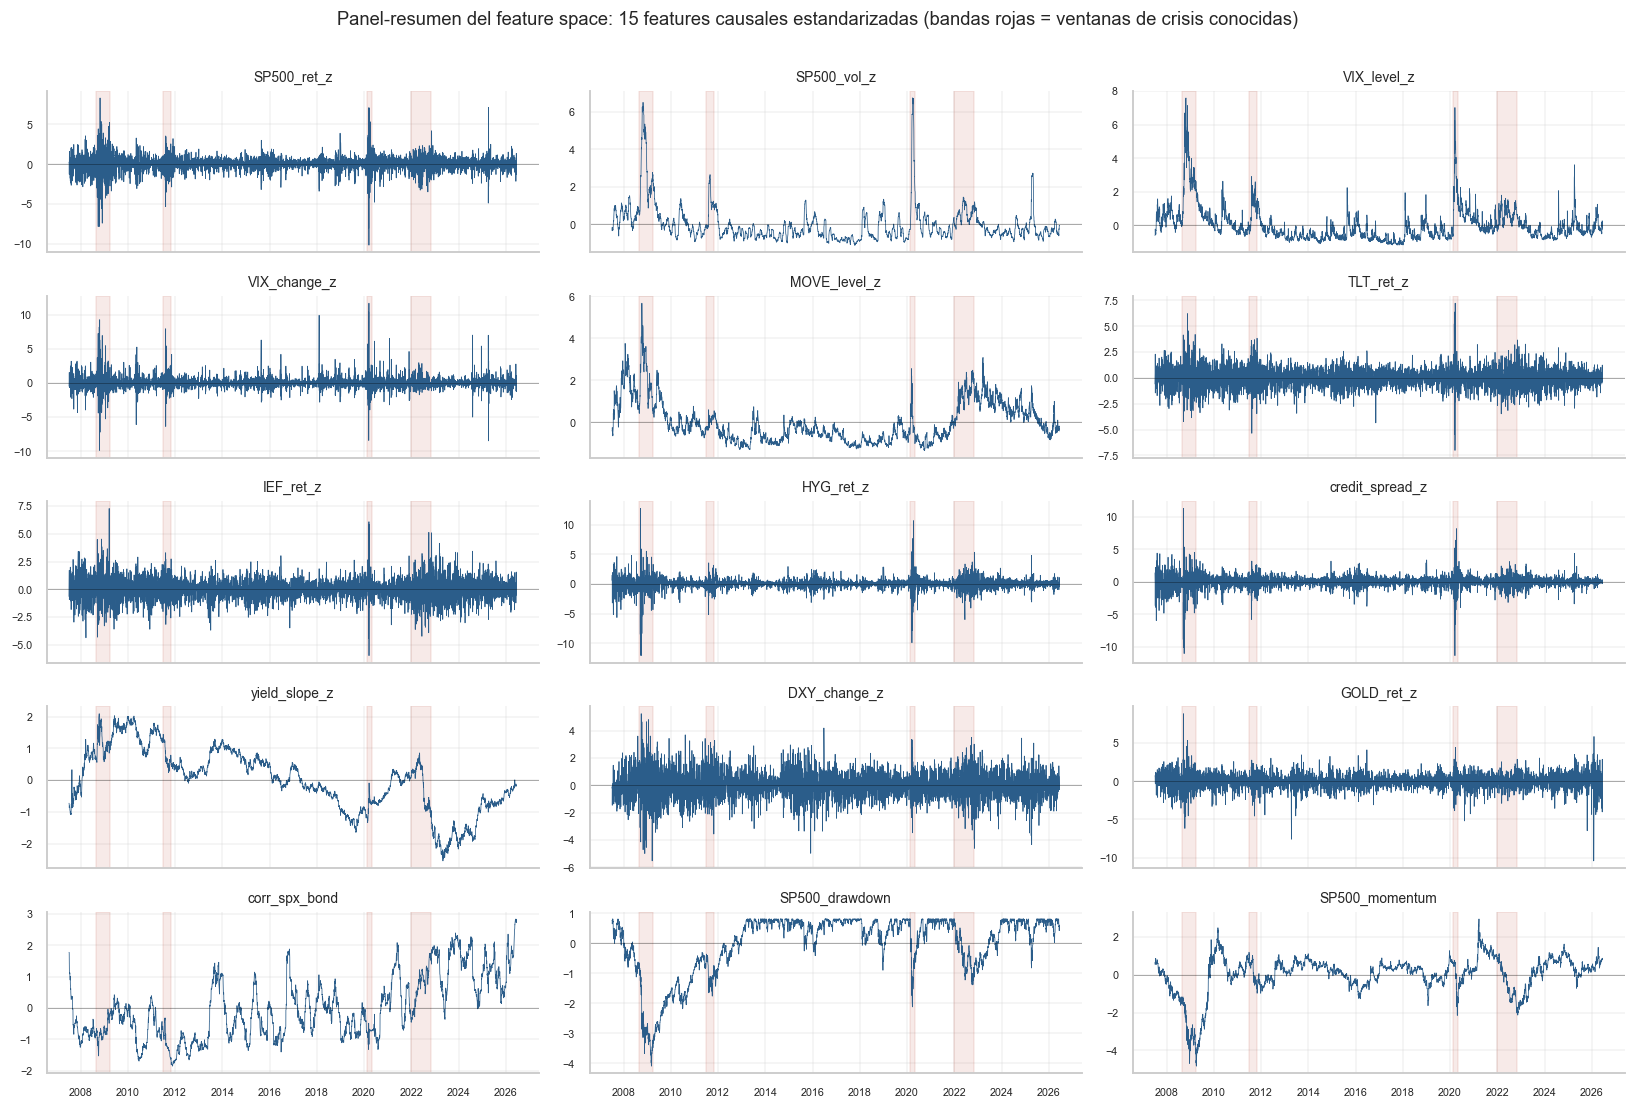

In [16]:
# Small multiples: las 15 features causales, cada una en su mini-serie temporal.
# Se muestran ESTANDARIZADAS (z de display sobre su propia columna) solo para que
# compartan escala; NO altera features.parquet (las features ya son causales).
fcols = list(feats.columns)
disp = (feats - feats.mean()) / feats.std()
ncol = 3
nrow = int(np.ceil(len(fcols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.0 * nrow), sharex=True)
axflat = axes.ravel()
for ax, col in zip(axflat, fcols):
    ax.plot(disp.index, disp[col], color=viz.C_LONG, lw=0.5)
    ax.axhline(0, color='black', lw=0.4, alpha=0.5)
    for a, b in ev.CRISIS_WINDOWS.values():
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=viz.C_CRISIS, alpha=0.10)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axflat[len(fcols):]:
    ax.axis('off')
fig.suptitle('Panel-resumen del feature space: 15 features causales estandarizadas '
             '(bandas rojas = ventanas de crisis conocidas)', y=1.005, fontsize=12)
fig.tight_layout(); fig.savefig(RESULTS / 'eda_features_overview.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="sec-14"></a>
## 14. Tabla de estadísticos por feature

Cerramos con una *tabla-figura* (vía `viz.render_table_figure`, embebible en el informe LaTeX sin depender de Stylers de pandas) que resume cada una de las 15 features: media y desviación (los z deberían rondar 0 y 1; las tres features crudas —`corr_spx_bond`, `SP500_drawdown`, `SP500_momentum`— viven en su escala natural), rango, kurtosis de exceso y el **porcentaje de días extremos** (|z|>3 sobre la propia columna). Las features de estrés muestran las colas más gruesas, coherente con que son las que disparan en crisis. Es la ficha técnica compacta del artefacto que heredan los 12 detectores.

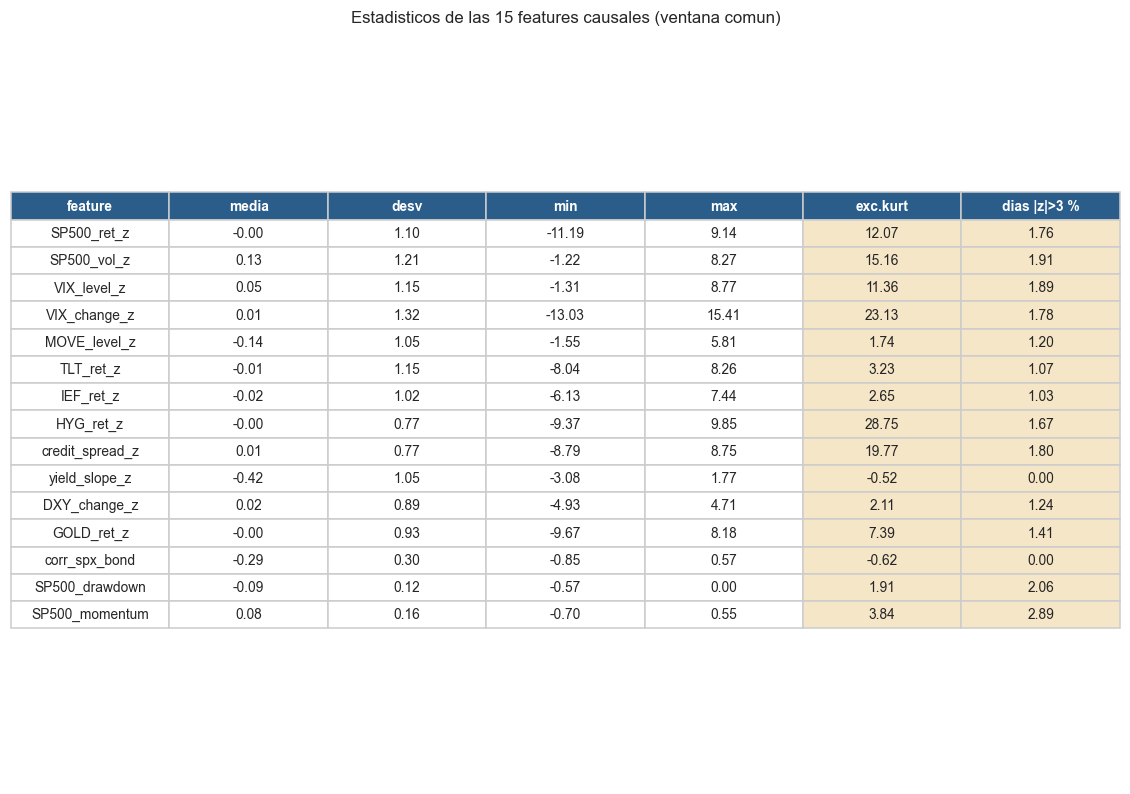

In [17]:
z = (feats - feats.mean()) / feats.std()
stat = pd.DataFrame({
    'media': feats.mean(),
    'desv': feats.std(),
    'min': feats.min(),
    'max': feats.max(),
    'exc.kurt': feats.kurtosis(),
    'dias |z|>3 %': (z.abs() > 3).mean() * 100,
})
stat.index.name = 'feature'
fig = viz.render_table_figure(
    stat, title='Estadisticos de las 15 features causales (ventana comun)',
    highlight_cols=['exc.kurt', 'dias |z|>3 %'], fmt='{:.2f}')
fig.savefig(RESULTS / 'eda_features_stats.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="sec-fin"></a>

---
**Conclusión FASE 1.** Queda fijado el terreno común sobre el que competirán los detectores: datos descargados **sin imputar**, ventana común **2007-04-11 → 2026-06** (gobernada por HYG), **15 features causales** verificadas como libres de look-ahead, distribuciones con **colas gordas** documentadas (relevante para los modelos gaussianos) y suelos de drawdown calculados para anclar el lead/lag. La honestidad metodológica —no imputar, no mirar al futuro, documentar cada sustitución de fuente— es deliberada: sin ella, cualquier comparación posterior de detectores sería sospechosa.

El recorrido visual lo resume en cuatro miradas complementarias: el **timeline de cobertura** (por qué 2007-04), el contraste de **retornos crisis vs calma** (de dónde salen las colas gordas), el **panel de las 15 features** (qué se enciende en cada crisis) y la **ficha de estadísticos** por feature. Sobre esta base arrancan D1 (regla de VIX) y D2 (voto compuesto). Detalle en `docs/memory/01_data_and_eda.md`.